# Acoustic Uroflowmetry Prototype
Estimate urinary flow rate from sound using DSP features and similarity search.

Pipeline:
1. Calibration from known flows
2. Feature extraction (MFCC + spectral features) with Digital Signal Processing
3. RMS-based segmentation
4. KNN similarity to estimate flow per segment
5. Plot uroflow curve


In [73]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

import operator

from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# from sklearn.ensemble import RandomForestClassifier

import glob
import os





## Feature Extraction

In [ ]:
def extract_features_old(y, sr):
    features = []

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    features.extend(np.mean(mfcc, axis=1))

    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.append(np.mean(spec_centroid))

    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.append(np.mean(spec_bandwidth))

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features.append(np.mean(rolloff))

    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))

    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))


        
    return np.array(features)


In [119]:
def extract_features(y, sr):

    # -------------------------
    # 0️⃣ Pré-traitement robuste micro
    # -------------------------
    
    # Enlève les très basses fréquences (bruits de pièce)
    y = librosa.effects.preemphasis(y)

    # =========================
    # 1️⃣ MFCC (texture globale)
    # =========================
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
        n_fft=2048,
        hop_length=512
    )

    # Normalisation cepstrale (CMVN) : stabilise les MFCC entre micros
    # mfcc = (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / \
    #        (np.std(mfcc, axis=1, keepdims=True) + 1e-8)
    mfcc = mfcc - np.mean(mfcc, axis=1, keepdims=True)

    features = []
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))

    # =========================
    # 2️⃣ Features spectrales
    # =========================
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.append(np.mean(spec_centroid))
    features.append(np.std(spec_centroid))

    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.append(np.mean(spec_bandwidth))
    features.append(np.std(spec_bandwidth))

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    features.append(np.mean(rolloff))
    features.append(np.std(rolloff))

    # =========================
    # 3️⃣ Bruit vs tonal
    # =========================
    spec_flatness = librosa.feature.spectral_flatness(y=y)
    features.append(np.mean(spec_flatness))
    features.append(np.std(spec_flatness))

    # =========================
    # 4️⃣ Dynamique / énergie
    # =========================
    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))
    features.append(np.std(rms))

    # =========================
    # 5️⃣ Rugosité temporelle
    # =========================
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    # =========================
    # 6️⃣ Flux spectral (variation du spectre dans le temps)
    # Très corrélé aux turbulences et donc au débit
    # Plus le flux est élevé, plus le jet est turbulent / intense
    # =========================
    # Calcul du spectrogramme magnitude
    S = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
    # Flux spectral : différence entre frames successives
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0)) / S.shape[0]
    features.append(np.mean(flux))
    features.append(np.std(flux))

    return np.array(features)


In [ ]:
def extract_features_old(y, sr):
    '''
    BUT : Extraire de l’information physique mesurable (features) à partir du signal sonore brut
    
    Un jet d’urine qui frappe l’eau :

    crée des bulles
    crée des micro-turbulences
    génère un bruit proche d’un bruit blanc filtré

    Il n’y a pas de fréquence fondamentale stable.'''


    # TODO: pensez à mettre dns les sons étalons des silences débit = 0 (3 bruits blancs minimum)
    
    features = []

    # =========================
    # 1️⃣ MFCC (texture globale)
    # =========================
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))  # variabilité temporelle

    # =========================
    # 2️⃣ Features spectrales (bruit)
    # =========================
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.append(np.mean(spec_centroid))
    features.append(np.std(spec_centroid))

    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.append(np.mean(spec_bandwidth))
    features.append(np.std(spec_bandwidth))

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    features.append(np.mean(rolloff))
    features.append(np.std(rolloff))

    # =========================
    # 3️⃣ Flatness (bruit vs tonal)
    # =========================
    spec_flatness = librosa.feature.spectral_flatness(y=y)
    features.append(np.mean(spec_flatness))
    features.append(np.std(spec_flatness))

    # =========================
    # 4️⃣ Dynamique / énergie
    # =========================
    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))
    features.append(np.std(rms))

    # =========================
    # 5️⃣ Rugosité temporelle
    # =========================
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    return np.array(features)


## RMS-based Segmentation

In [76]:
def segment_audio(y, sr, frame_duration=0.2, threshold=0.01):
    
    frame_length = int(frame_duration * sr)
    rms = librosa.feature.rms(y=y, frame_length=frame_length)[0]

    segments = []
    start = None

    for i, val in enumerate(rms):
        if val > threshold and start is None:
            start = i
        elif val <= threshold and start is not None:
            end = i
            segments.append((start, end))
            start = None

    return segments, frame_length


## Build Calibration Dataset

In [106]:
def build_calibration_dataset(folder='calibration_sounds'):
    rows = []
    # ⚠️ IMPORTANT : définir les noms de colonnes
    feature_names = [
        # ---- MFCC (13 x mean)
        "mfcc1_mean","mfcc2_mean","mfcc3_mean","mfcc4_mean","mfcc5_mean",
        "mfcc6_mean","mfcc7_mean","mfcc8_mean","mfcc9_mean","mfcc10_mean",
        "mfcc11_mean","mfcc12_mean","mfcc13_mean",
    
        # ---- MFCC (13 x std)
        "mfcc1_std","mfcc2_std","mfcc3_std","mfcc4_std","mfcc5_std",
        "mfcc6_std","mfcc7_std","mfcc8_std","mfcc9_std","mfcc10_std",
        "mfcc11_std","mfcc12_std","mfcc13_std",
    
        # ---- Spectral centroid
        "spec_centroid_mean","spec_centroid_std",
    
        # ---- Spectral bandwidth
        "spec_band_mean","spec_band_std",
    
        # ---- Spectral rolloff
        "spec_rolloff_mean","spec_rolloff_std",
    
        # ---- Spectral flatness
        "spec_flat_mean","spec_flat_std",
        
        # ---- RMS
        "rms_mean","rms_std",

        # ---- Zero Crossing Rate
        "zero_cross_rate_mean","zero_cross_rate_std",

        # ---- Flux spectral
        "flux_mean","flux_std",
    
        # ---- Target
        "debit"
    ]

    files = glob.glob(os.path.join(folder, "*.wav"))

    files_sorted = sorted(
        files,
        key=lambda x: float(os.path.basename(x).split("_")[0])
    )
    # files_sorted = sorted(files)

    for file in files_sorted:
        
        # debit = float(os.path.basename(file).split('_')[0].replace('mls.wav',''))
        debit = float(os.path.basename(file).partition('_')[0])

                
        print(debit)
        y, sr = librosa.load(file, sr=32000)
        
        # Visualisation des fréquences
        S = np.abs(librosa.stft(y))
        freqs = librosa.fft_frequencies(sr=sr)

        # moyenne temporelle
        mean_spectrum = np.mean(S, axis=1)

        # plt.plot(freqs, mean_spectrum)
        # plt.xlabel("Fréquence (Hz)")
        # plt.ylabel("Amplitude")
        # plt.show()

        # fin graphique
        
        feat = extract_features(y, sr)
        rows.append(np.append(feat, debit))

    

    df = pd.DataFrame(rows,columns=feature_names)
    # df = pd.DataFrame(rows)
    df.to_csv('calibration_features.csv', index=False)
    print('Calibration dataset saved.')

    


In [117]:
def build_dataset(folder='sons_tests', margin_sec=3):
    rows = []

    feature_names = [
        "mfcc1_mean","mfcc2_mean","mfcc3_mean","mfcc4_mean","mfcc5_mean",
        "mfcc6_mean","mfcc7_mean","mfcc8_mean","mfcc9_mean","mfcc10_mean",
        "mfcc11_mean","mfcc12_mean","mfcc13_mean",

        "mfcc1_std","mfcc2_std","mfcc3_std","mfcc4_std","mfcc5_std",
        "mfcc6_std","mfcc7_std","mfcc8_std","mfcc9_std","mfcc10_std",
        "mfcc11_std","mfcc12_std","mfcc13_std",

        "spec_centroid_mean","spec_centroid_std",
        "spec_band_mean","spec_band_std",
        "spec_rolloff_mean","spec_rolloff_std",
        "spec_flat_mean","spec_flat_std",
        "rms_mean","rms_std",
        "zero_cross_rate_mean","zero_cross_rate_std",
        "flux_mean","flux_std",
        "debit"
    ]

    files = glob.glob(os.path.join(folder, "*.wav"))

    files_sorted = sorted(
        files,
        key=lambda x: float(os.path.basename(x).split("_")[0])
    )

    for file in files_sorted:

        debit = float(os.path.basename(file).partition('_')[0])

        y, sr = librosa.load(file, sr=32000)

        # --- Détection du début et de la fin du signal utile
        yt, idx = librosa.effects.trim(y, top_db=20)

        start = max(0, idx[0] - int(margin_sec * sr))
        end = min(len(y), idx[1] + int(margin_sec * sr))

        y = y[start:end]

        # --- Normalisation RMS (robuste aux micros)
        rms = np.sqrt(np.mean(y**2))
        target_rms = 0.1
        y = y * (target_rms / (rms + 1e-8))

        # --- Normalisation amplitude
        '''suppressons essentiellement :

            le volume global du micro
            la distance au micro
            le gain automatique
            les différences de niveau entre appareils

            Donc on enlève une information qui n’est pas liée au débit réel, mais au matériel.'''
        y = librosa.util.normalize(y)

        feat = extract_features(y, sr)
        rows.append(np.append(feat, debit))

    df = pd.DataFrame(rows,columns=feature_names)
    df.to_csv(folder + "_features.csv", index=False)
    print(f'Calibration dataset saved as {folder}_features.csv')



In [ ]:
def build_test_dataset_old(folder='sons_tests'):
    rows = []
    # ⚠️ IMPORTANT : définir les noms de colonnes
    feature_names = [
        # ---- MFCC (13 x mean)
        "mfcc1_mean","mfcc2_mean","mfcc3_mean","mfcc4_mean","mfcc5_mean",
        "mfcc6_mean","mfcc7_mean","mfcc8_mean","mfcc9_mean","mfcc10_mean",
        "mfcc11_mean","mfcc12_mean","mfcc13_mean",
    
        # ---- MFCC (13 x std)
        "mfcc1_std","mfcc2_std","mfcc3_std","mfcc4_std","mfcc5_std",
        "mfcc6_std","mfcc7_std","mfcc8_std","mfcc9_std","mfcc10_std",
        "mfcc11_std","mfcc12_std","mfcc13_std",
    
        # ---- Spectral centroid
        "spec_centroid_mean","spec_centroid_std",
    
        # ---- Spectral bandwidth
        "spec_band_mean","spec_band_std",
    
        # ---- Spectral rolloff
        "spec_rolloff_mean","spec_rolloff_std",
    
        # ---- Spectral flatness
        "spec_flat_mean","spec_flat_std",
        
        # ---- RMS
        "rms_mean","rms_std",

        # ---- Zero Crossing Rate
        "zero_cross_rate_mean","zero_cross_rate_std",
    
        # ---- Target
        "debit"
    ]

    files = glob.glob(os.path.join(folder, "*.wav"))

    files_sorted = sorted(
        files,
        key=lambda x: float(os.path.basename(x).split("_")[0])
    )
    # files_sorted = sorted(files)

    for file in files_sorted:
        
        # debit = float(os.path.basename(file).split('_')[0].replace('mls.wav',''))
        debit = float(os.path.basename(file).partition('_')[0])

                
        # print(debit)
        y, sr = librosa.load(file, sr=32000)
        
        # Visualisation des fréquences
        S = np.abs(librosa.stft(y))
        freqs = librosa.fft_frequencies(sr=sr)

        # moyenne temporelle
        mean_spectrum = np.mean(S, axis=1)

        # plt.plot(freqs, mean_spectrum)
        # plt.xlabel("Fréquence (Hz)")
        # plt.ylabel("Amplitude")
        # plt.show()

        # fin graphique
        
        feat = extract_features(y, sr)
        rows.append(np.append(feat, debit))

    

  
    df = pd.DataFrame(rows,columns=feature_names)
    df.to_csv(folder + "_features.csv", index=False)
    print(f'Calibration dataset saved as {folder}_features.csv')
    

    


In [118]:

build_dataset('sons_tests')

df_test=pd.read_csv("sons_tests_features.csv", sep=",")

Calibration dataset saved as sons_tests_features.csv


In [120]:
build_dataset('calibration_sounds')

df=pd.read_csv("calibration_sounds_features.csv", sep=",")

Calibration dataset saved as calibration_sounds_features.csv


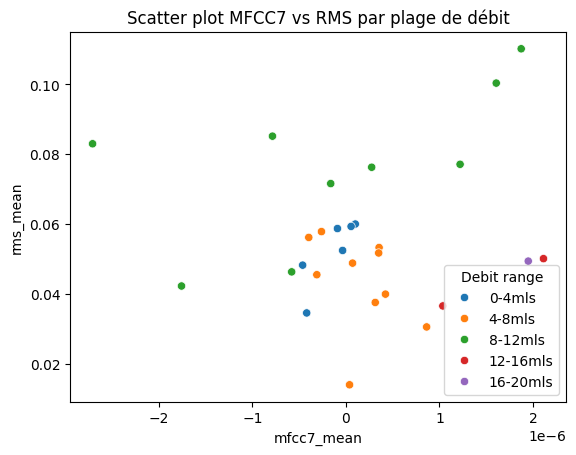

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# # 1️⃣ Charger les données
# df = pd.read_csv("calibration_features.csv", sep=",")

# 2️⃣ Définir les bornes des plages
bins = [0, 4, 8, 12, 16, 20]
labels = ["0-4mls", "4-8mls", "8-12mls", "12-16mls", "16-20mls"]

# 3️⃣ Créer la nouvelle variable catégorielle
df["debit_range"] = pd.cut(
    df["debit"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 4️⃣ Créer le nouveau dataframe
df_new = df[["mfcc7_mean", "rms_mean", "debit_range"]]


plt.figure()

sns.scatterplot(
    data=df_new,
    x="mfcc7_mean",
    y="rms_mean",
    hue="debit_range"
)

plt.xlabel("mfcc7_mean")
plt.ylabel("rms_mean")
plt.title("Scatter plot MFCC7 vs RMS par plage de débit")

plt.legend(title="Debit range")
plt.show()



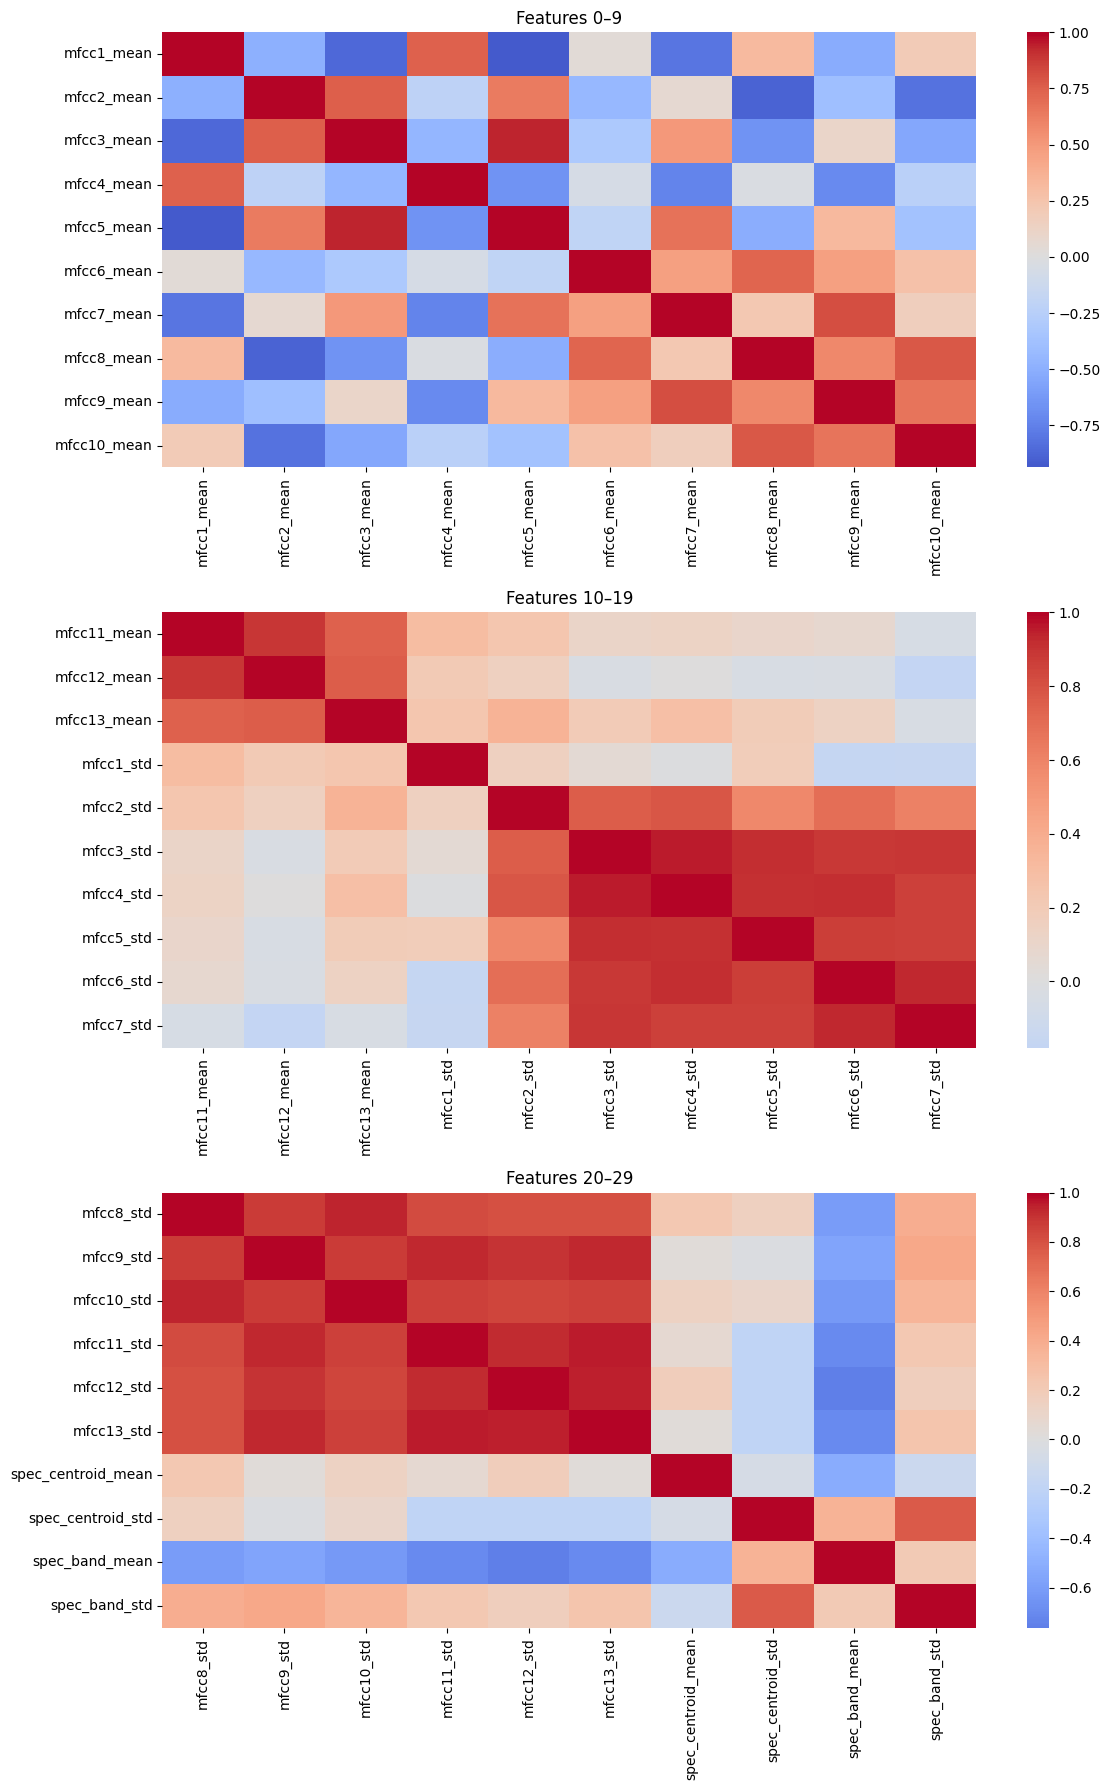

In [82]:
# recherche correlations
import matplotlib.pyplot as plt
import seaborn as sns

# Sélection des blocs
Z1 = df.iloc[:, 0:10]
Z2 = df.iloc[:, 10:20]
Z3 = df.iloc[:, 20:30]

# Création figure avec 3 lignes, 1 colonne
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Heatmap 1
sns.heatmap(Z1.corr(numeric_only=True),
            ax=axes[0],
            cmap="coolwarm",
            center=0)
axes[0].set_title("Features 0–9")

# Heatmap 2
sns.heatmap(Z2.corr(numeric_only=True),
            ax=axes[1],
            cmap="coolwarm",
            center=0)
axes[1].set_title("Features 10–19")

# Heatmap 3
sns.heatmap(Z3.corr(numeric_only=True),
            ax=axes[2],
            cmap="coolwarm",
            center=0)
axes[2].set_title("Features 20–29")

plt.tight_layout()
plt.show()

In [122]:
df[["mfcc7_mean","spec_rolloff_mean", "debit"]].corr()

,mfcc7_mean,spec_rolloff_mean,debit
mfcc7_mean,1.000000,-0.064084,0.296585
spec_rolloff_mean,-0.064084,1.000000,-0.684560
debit,0.296585,-0.684560,1.000000


In [123]:
from sklearn.linear_model import LinearRegression

X_single = df[["mfcc7_mean"]]
y = df["debit"]

model = LinearRegression()
model.fit(X_single, y)

r2 = model.score(X_single, y)
print("R² avec mfcc7_mean seul :", r2)

R² avec mfcc7_mean seul : 0.08796276642454559


## Load Calibration and Prepare KNN

In [124]:
def load_knn_model(csv_path='calibration_features.csv', k=3):
    calib = pd.read_csv(csv_path)
    
    # X = features
    X_calib = calib.iloc[:, :-1].values
    
    # y = débit (target)
    y_calib = calib.iloc[:, -1].values

    # Modèle supervisé
    model = KNeighborsRegressor(
        n_neighbors=k,
        metric='euclidean',
        weights='distance'   # ou'uniform', 'distance' si tu veux pondérer par proximité
    )
    
    model.fit(X_calib, y_calib)

    return model



In [125]:
calib = pd.read_csv("calibration_features.csv", sep=",")

X = calib.iloc[:, :-1]
y = calib.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

FileNotFoundError: [Errno 2] No such file or directory: 'calibration_features.csv'

In [87]:
jeu_test_real = pd.read_csv("test_features.csv", sep=",")

X_real = jeu_test_real.iloc[:, :-1]
y_real = jeu_test_real.iloc[:, -1]



0.981967774228891


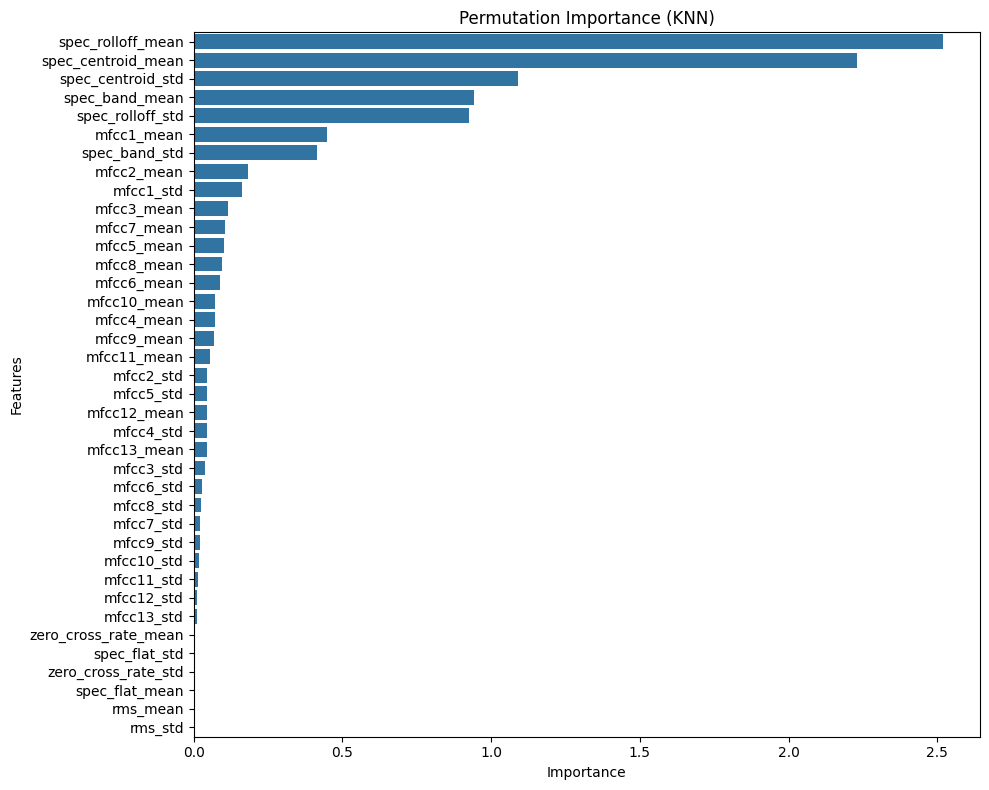

In [88]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

'''Principe :

On mesure la performance du modèle

On mélange une feature

On regarde combien la performance chute

Si elle chute beaucoup → feature importante.'''

# Fit modèle
rf_nn = KNeighborsRegressor(
    n_neighbors=3,
    metric='euclidean',
    weights='distance'
)

test = KNeighborsRegressor(
    n_neighbors=3,
    metric='euclidean',
    weights='distance'
)

rf_nn.fit(X, y)

test.fit(X_train, y_train)

# Permutation importance
result = permutation_importance(
    rf,
    X,
    y,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)
print(test.score(X_test, y_test))
plt.title("Permutation Importance (KNN)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [102]:
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = test.predict(X_test)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

   y_test     y_pred    erreur
0    4.99   5.160807  0.170807
1   13.69  14.408551  0.718551
2    4.54   4.447649  0.092351
3   10.00   8.897717  1.102283
4    0.00   0.022160  0.022160
5    5.55   6.071456  0.521456
MAE: 0.44


In [103]:
# Prédictions
y_pred_real = rf_nn.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

    y_test     y_pred    erreur
0    8.930  16.180306  7.250306
1    9.290   4.337690  4.952310
2    9.300   9.489295  0.189295
3   10.090  16.165827  6.075827
4   10.430   9.817539  0.612461
5   11.049   9.522321  1.526679
6   11.120   4.337363  6.782637
7   11.760   9.311524  2.448476
8   12.500  13.208645  0.708645
9   18.650  13.284756  5.365244
10  21.270  15.811965  5.458035
MAE: 3.76


0.9877903726786256


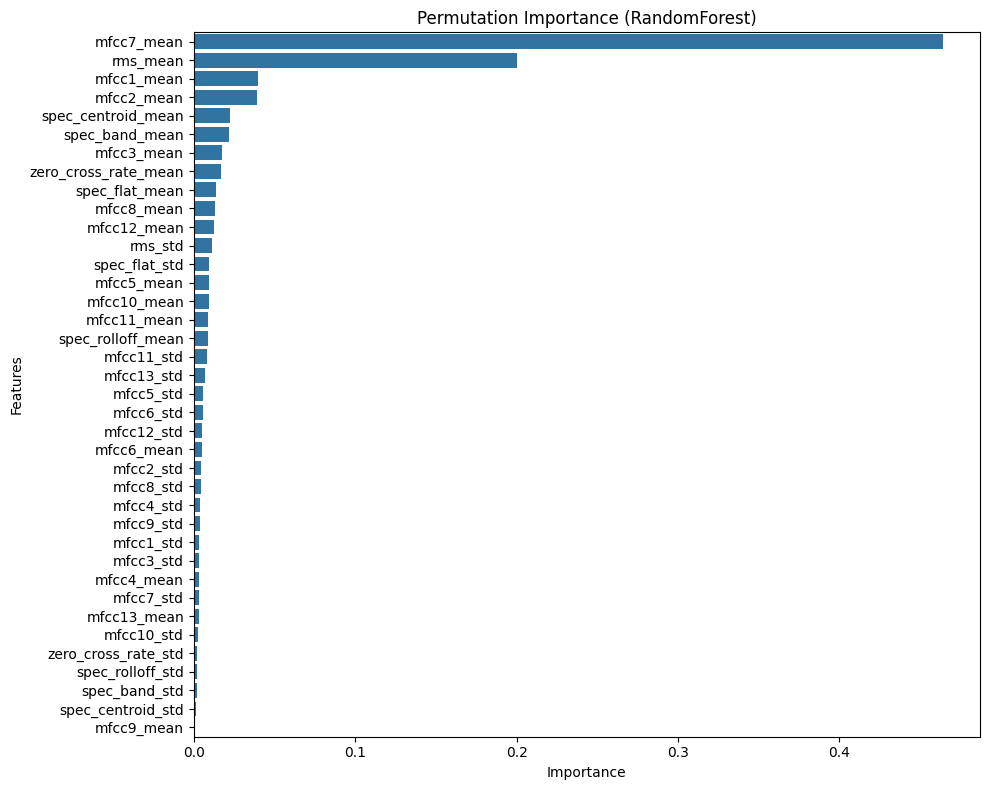

In [92]:
from sklearn.ensemble import RandomForestRegressor

# entrainement tout le set de données
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X, y)

train_model = RandomForestRegressor(random_state=42)
train_model.fit(X_train, y_train)

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)
print(train_model.score(X_test, y_test))
plt.title("Permutation Importance (RandomForest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [93]:
y_real_pred = rf_model.predict(X_real)
y_real
print(y_real)
print(y_real_pred)
mae=round(mean_absolute_error(y_real, y_real_pred),2)

print("MAE:", mae)

0      8.930
1      9.290
2      9.300
3     10.090
4     10.430
5     11.049
6     11.120
7     11.760
8     12.500
9     18.650
10    21.270
Name: debit, dtype: float64
[ 8.2145  3.7082  9.8754  7.7879 10.3035 10.3409  5.4685  9.9016 11.4048
  4.2313  4.3166]
MAE: 4.54


Rappel : qu’est-ce que mfcc7_mean ?

Les MFCC (Mel-Frequency Cepstral Coefficients) décrivent :

la forme du spectre

la structure fréquentielle globale

le “timbre” du signal

mfcc7_mean = moyenne temporelle du 7ᵉ coefficient.

👉 Donc c’est une information spectrale compressée.

Si le débit influence :

    la pression

    la turbulence

    le bruit généré

    la répartition énergétique dans le spectre

Alors il est plausible qu’un MFCC soit corrélé au débit.

In [94]:
y_test
y_pred = train_model.predict(X_test)
print(y_test)
print(y_pred)
mae=round(mean_absolute_error(y_test, y_pred),2)
print("MAE:", mae)

9      4.99
25    13.69
8      4.54
21    10.00
0      0.00
12     5.55
Name: debit, dtype: float64
[ 4.8706 14.064   3.9394  9.4517  0.7     5.8271]
MAE: 0.44


In [95]:
from sklearn.feature_selection import SelectKBest, f_regression

# mesure corrélation linéaire uniquement!!

selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X_calib, y_calib)



importances = selector.scores_
indices = np.argsort(scores)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Permutation Importance (SelectKBest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

NameError: name 'X_calib' is not defined

## Estimate Flow for a Segment

In [ ]:
def estimate_flow(feat, model):
    """
    feat : vecteur features 1D (35 features par ex.)
    model : modèle KNeighborsRegressor déjà entraîné
    """
    
    feat = np.array(feat).reshape(1, -1)  # nécessaire pour sklearn
    prediction = model.predict(feat)

    return prediction[0]


## Analyze a Real Recording

In [ ]:
def analyze_recording(file_path, nn, y_calib):
    y, sr = librosa.load(file_path, sr=32000)
    segments, frame_len = segment_audio(y, sr)

    results = []

    for i, (s, e) in enumerate(segments):
        seg = y[s*frame_len:e*frame_len]
        feat = extract_features(seg, sr)
        debit = estimate_flow(feat, nn, y_calib)
        duration = (e - s) * 0.2
        results.append({"phase": i+1, "debit": debit, "duree": duration})

    return results


## Plot Uroflow Curve

In [ ]:
def plot_uroflow(results):
    times = []
    flows = []
    t = 0

    for r in results:
        times.append(t)
        flows.append(r['debit'])
        t += r['duree']

    plt.step(times, flows)
    plt.xlabel('Time (s)')
    plt.ylabel('Flow (ml/s)')
    plt.title('Estimated Uroflow Curve')
    plt.show()
